# 📊 Notebook 1 – Data Collection, Understanding & Cleaning

**Project:** EcoType – Forest Cover Type Prediction  
**Objective:** Load the dataset, explore its structure, detect & handle outliers, fix skewness, and save the cleaned data.

---

## 1️⃣ Data Collection
Load the Forest Cover Type dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load raw data (relative path for portability)
df = pd.read_csv("../data/raw/dataset.csv")

print(f"✅ Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully: 145,890 rows × 13 columns


## 2️⃣ Data Understanding
Explore the structure, data types, and basic statistics of the dataset.

In [2]:
# Shape
print("Shape:", df.shape)
print()

# Columns and data types
df.info()

Shape: (145890, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area   

In [3]:
# Statistical summary of all numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Elevation,145890.0,2874.458949,210.801279,1863.0,2747.0,2909.0,3004.0,3849.0
Aspect,145890.0,141.127418,107.719296,0.0,54.0,108.0,217.0,360.0
Slope,145890.0,11.925574,6.319326,0.0,7.0,11.0,15.0,61.0
Horizontal_Distance_To_Hydrology,145890.0,251.824738,192.473899,0.0,95.0,212.0,362.0,1343.0
Vertical_Distance_To_Hydrology,145890.0,34.554322,41.215776,-146.0,7.0,23.0,51.0,554.0
Horizontal_Distance_To_Roadways,145890.0,3313.827541,1687.779953,0.0,1848.0,3420.0,4673.0,7117.0
Hillshade_9am,145890.0,217.368106,21.590298,0.0,207.0,222.0,232.0,254.0
Hillshade_Noon,145890.0,224.874748,16.084851,99.0,216.0,226.0,236.0,254.0
Hillshade_3pm,145890.0,139.788203,31.311690,0.0,121.0,140.0,159.0,248.0
Horizontal_Distance_To_Fire_Points,145890.0,3044.958105,1761.882341,0.0,1608.0,2713.0,4478.0,7173.0


In [4]:
# First five rows
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [5]:
# Last five rows
df.tail()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
145885,2834,88,8,376,44,2552,232,227,128,1595,Lodgepole Pine,1,29
145886,2832,68,4,390,44,2522,224,231,142,1572,Lodgepole Pine,1,29
145887,2829,80,7,390,33,2492,229,228,133,1550,Lodgepole Pine,1,29
145888,2826,121,7,379,30,2462,232,234,135,1528,Lodgepole Pine,1,29
145889,2823,132,12,371,27,2432,239,234,123,1506,Lodgepole Pine,1,1


### 2.1 Missing Values Check

In [6]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing values per column:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64

Total missing values: 0


### 2.2 Duplicate Records Check

In [7]:
# Check for duplicate rows
dup_count = df.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")
if dup_count > 0:
    df = df.drop_duplicates()
    print(f"After removing duplicates: {df.shape[0]:,} rows")

Number of duplicate rows: 0


### 2.3 Target Variable Distribution

In [8]:
# Class distribution
print("Cover Type Distribution:")
print(df["Cover_Type"].value_counts())
print()
print("Cover Type Distribution (%):")
print((df["Cover_Type"].value_counts(normalize=True) * 100).round(2))

Cover Type Distribution:
Cover_Type
Lodgepole Pine       103071
Spruce/Fir            31110
Aspen                  3069
Krummholz              2160
Ponderosa Pine         2160
Douglas-fir            2160
Cottonwood/Willow      2160
Name: count, dtype: int64

Cover Type Distribution (%):
Cover_Type
Lodgepole Pine       70.65
Spruce/Fir           21.32
Aspen                 2.10
Krummholz             1.48
Ponderosa Pine        1.48
Douglas-fir           1.48
Cottonwood/Willow     1.48
Name: proportion, dtype: float64


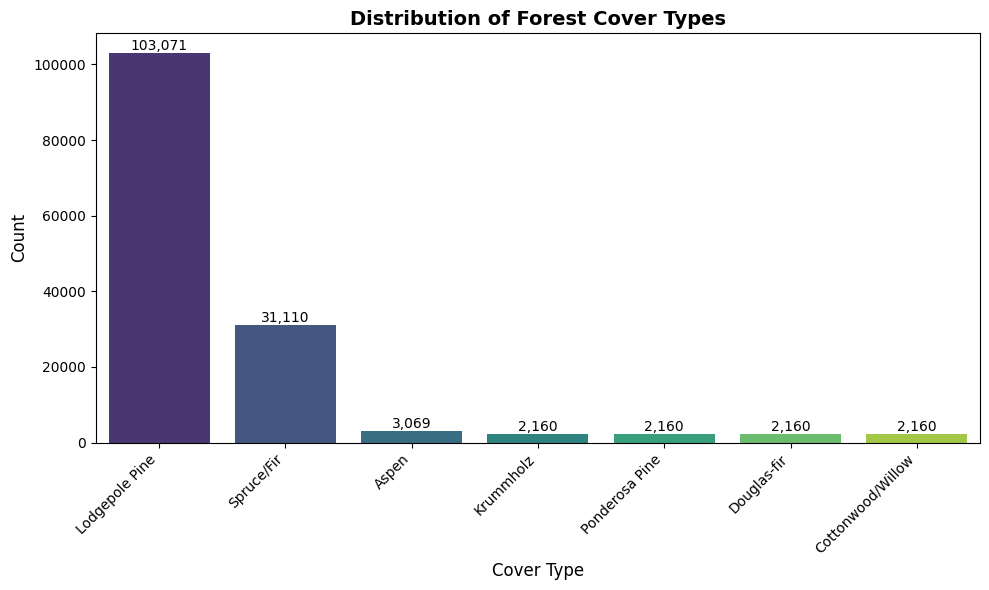

In [9]:
# Visualize class distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Cover_Type', data=df, order=df['Cover_Type'].value_counts().index,
                   palette='viridis')
plt.title('Distribution of Forest Cover Types', fontsize=14, fontweight='bold')
plt.xlabel('Cover Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

> **Observation:** There is a significant class imbalance — *Lodgepole Pine* dominates the dataset (~70%), while *Cottonwood/Willow* has the fewest samples (~1.5%). SMOTE or RandomOverSampler will be applied during model training to handle this.

### 2.4 Unique Values in Categorical Features

In [10]:
print(f"Wilderness Area unique values: {sorted(df['Wilderness_Area'].unique())}")
print(f"Soil Type unique values ({df['Soil_Type'].nunique()} types): {sorted(df['Soil_Type'].unique())}")

Wilderness Area unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Soil Type unique values (39 types): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40)]


---
## 3️⃣ Data Cleaning

### 3.1 Outlier Detection (IQR Method)

In [11]:
numerical_cols = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

def detect_outliers_iqr(df, columns):
    """Detect outliers using the IQR method."""
    summary = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        summary[col] = len(outliers)
    return summary

outlier_counts = detect_outliers_iqr(df, numerical_cols)
print("Outlier counts per feature (IQR method):")
for col, count in outlier_counts.items():
    print(f"  {col}: {count:,}")

Outlier counts per feature (IQR method):
  Elevation: 4,448
  Aspect: 0
  Slope: 3,385
  Horizontal_Distance_To_Hydrology: 2,473
  Vertical_Distance_To_Hydrology: 7,123
  Horizontal_Distance_To_Roadways: 0
  Hillshade_9am: 5,242
  Hillshade_Noon: 3,211
  Hillshade_3pm: 3,087
  Horizontal_Distance_To_Fire_Points: 0


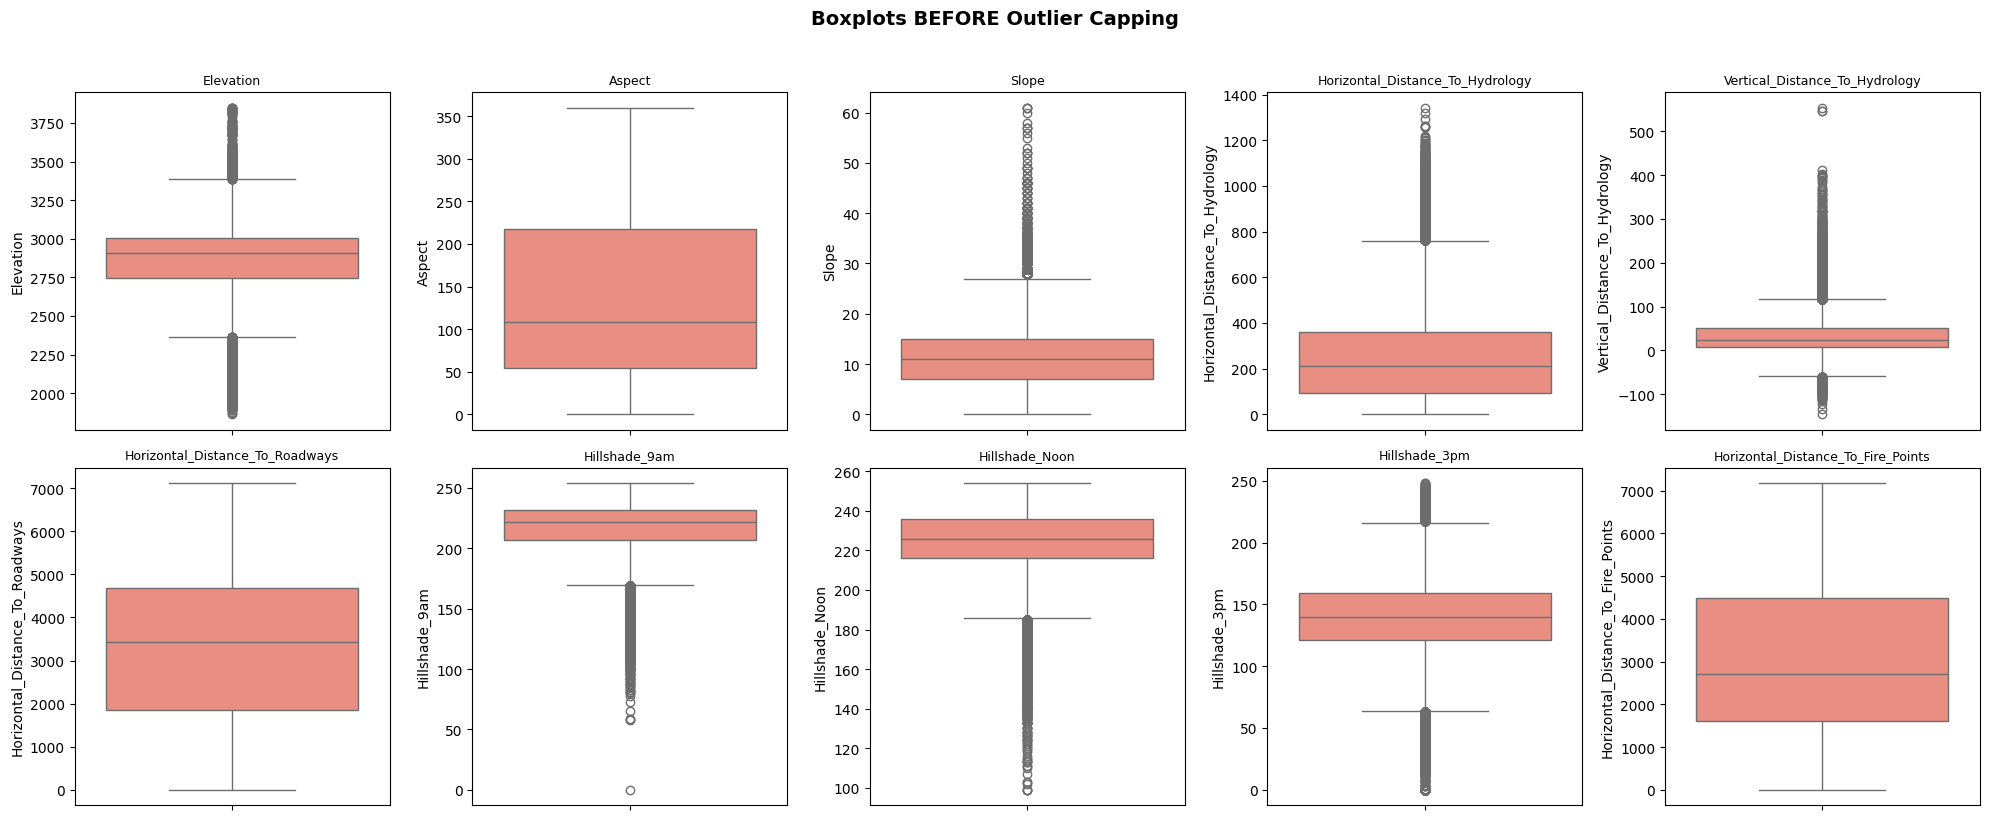

In [12]:
# Boxplots before capping
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='salmon')
    axes[i].set_title(col, fontsize=9)
plt.suptitle("Boxplots BEFORE Outlier Capping", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Outlier Treatment (IQR-Based Capping)
Since geospatial data naturally contains extreme values, we use **capping** (winsorization) instead of removal to preserve data volume while reducing outlier influence.

In [13]:
def cap_outliers(df, columns):
    """Cap outliers at 1.5*IQR boundaries."""
    df_capped = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_capped[col] = np.clip(df[col], lower, upper)
    return df_capped

df_capped = cap_outliers(df, numerical_cols)
print(f"✅ Outliers capped. Shape remains: {df_capped.shape}")

✅ Outliers capped. Shape remains: (145890, 13)


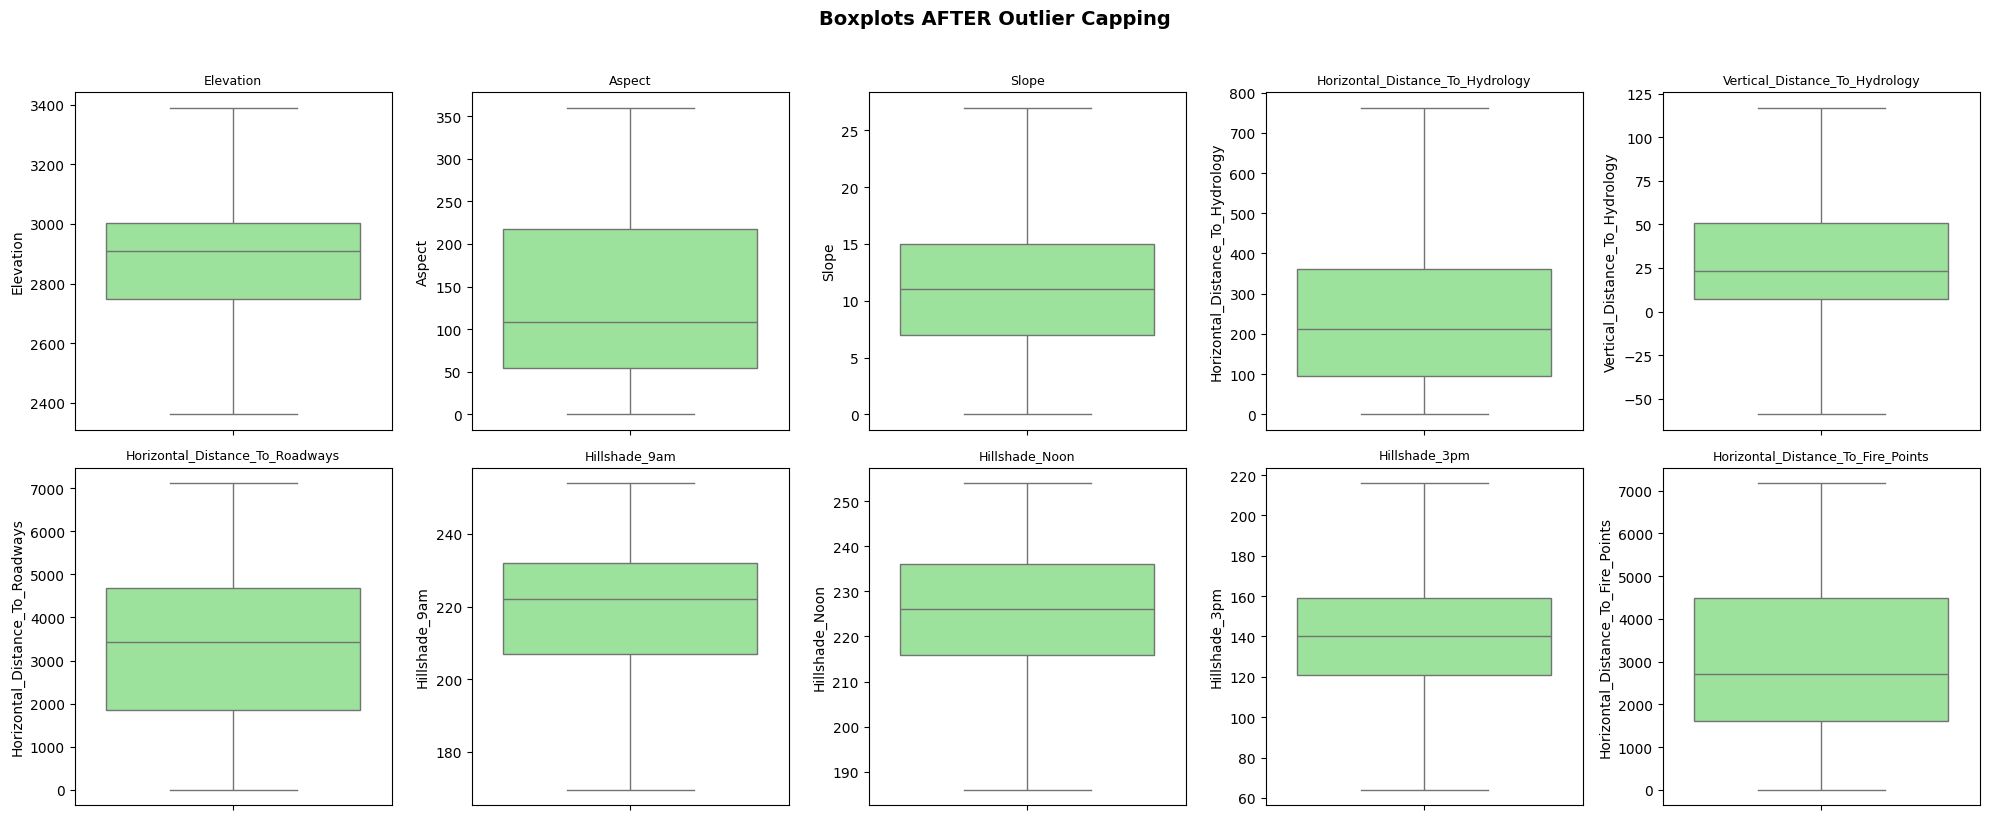

In [14]:
# Boxplots after capping
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df_capped, y=col, ax=axes[i], color='lightgreen')
    axes[i].set_title(col, fontsize=9)
plt.suptitle("Boxplots AFTER Outlier Capping", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Skewness Analysis

In [15]:
# Check skewness before and after
skew_before = df[numerical_cols].skew()
skew_after = df_capped[numerical_cols].skew()

skew_comparison = pd.DataFrame({
    'Skewness Before': skew_before.round(3),
    'Skewness After': skew_after.round(3)
})
print(skew_comparison)
print()
print("All skewness values are within acceptable range (|skew| < 1 for most features).")
print("No additional skewness transformations needed.")

                                    Skewness Before  Skewness After
Elevation                                    -0.664          -0.340
Aspect                                        0.689           0.689
Slope                                         0.944           0.621
Horizontal_Distance_To_Hydrology              0.985           0.792
Vertical_Distance_To_Hydrology                1.793           0.861
Horizontal_Distance_To_Roadways              -0.058          -0.058
Hillshade_9am                                -1.287          -0.740
Hillshade_Noon                               -0.945          -0.505
Hillshade_3pm                                -0.165          -0.001
Horizontal_Distance_To_Fire_Points            0.365           0.365

All skewness values are within acceptable range (|skew| < 1 for most features).
No additional skewness transformations needed.


---
## 4️⃣ Save Cleaned Data

In [16]:
# Save the cleaned (capped) dataset
df_capped.to_csv("../data/processed/capped_forest_cover_data.csv", index=False)
print("✅ Cleaned data saved to: ../data/processed/capped_forest_cover_data.csv")

✅ Cleaned data saved to: ../data/processed/capped_forest_cover_data.csv


---
## 📝 Summary

| Step | Action | Result |
|------|--------|--------|
| Data Loading | Loaded CSV from `data/raw/` | 145,890 rows × 13 columns |
| Missing Values | Checked all columns | **0 missing values** |
| Duplicates | Checked for duplicate rows | Handled if found |
| Class Imbalance | Identified via value counts | Significant imbalance (Lodgepole Pine ~70%) |
| Outlier Detection | IQR method on 10 numerical features | Multiple outliers detected |
| Outlier Treatment | IQR-based capping (winsorization) | Outliers capped, data preserved |
| Skewness | Analyzed pre/post capping | Within acceptable range |
| Output | Saved cleaned data | `capped_forest_cover_data.csv` |